In [26]:
import pandas as pd
import numpy as np
df = pd.read_csv("2/list_attr_celeba.csv")
df = df.replace(-1, 0)
df = df.rename(columns={"image_id":"path"})

files = []
ids = []
with open("/vol/ideadata/ed52egek/pycharm/syneverything/datasets/celeba/identity_CelebA.txt") as fp: 
    for line in fp.readlines(): 
        file, id = line.split(" ")
        files.append(file)

        ids.append(int(id.rstrip("\n")))
df["id"] = ids

# Shuffle unique IDs
unique_ids = df["id"].unique()
np.random.seed(42)  # for reproducibility
np.random.shuffle(unique_ids)

# Split sizes
n_total = len(unique_ids)
n_train = int(0.6 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_ids = unique_ids[:n_train]
val_ids = unique_ids[n_train:n_train + n_val]
test_ids = unique_ids[n_train + n_val:]

# Assign split column
def assign_split(x):
    if x in train_ids:
        return "TRAIN"
    elif x in val_ids:
        return "VAL"
    else:
        return "TEST"

df["Split"] = df["id"].apply(assign_split)

df.to_csv("celeba.csv")
df.head()

,path,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,id,Split
0,000001.jpg,0,1,1,0,0,0,0,0,0,...,1,0,1,0,1,0,0,1,2880,TRAIN
1,000002.jpg,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,2937,TEST
2,000003.jpg,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,1,8692,TRAIN
3,000004.jpg,0,0,1,0,0,0,0,0,0,...,1,0,1,0,1,1,0,1,5805,TRAIN
4,000005.jpg,0,1,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,9295,TEST


In [24]:
df[df["id"] == 12]

,path,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,id,Split
2485,002486.jpg,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
2575,002576.jpg,0,0,1,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
3566,003567.jpg,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
20659,020660.jpg,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
21409,021410.jpg,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
22130,022131.jpg,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
28511,028512.jpg,0,0,1,0,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
28857,028858.jpg,0,0,1,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
46665,046666.jpg,0,0,1,0,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN
54123,054124.jpg,0,0,1,1,0,0,0,1,1,...,1,0,0,0,0,0,0,1,12,TRAIN


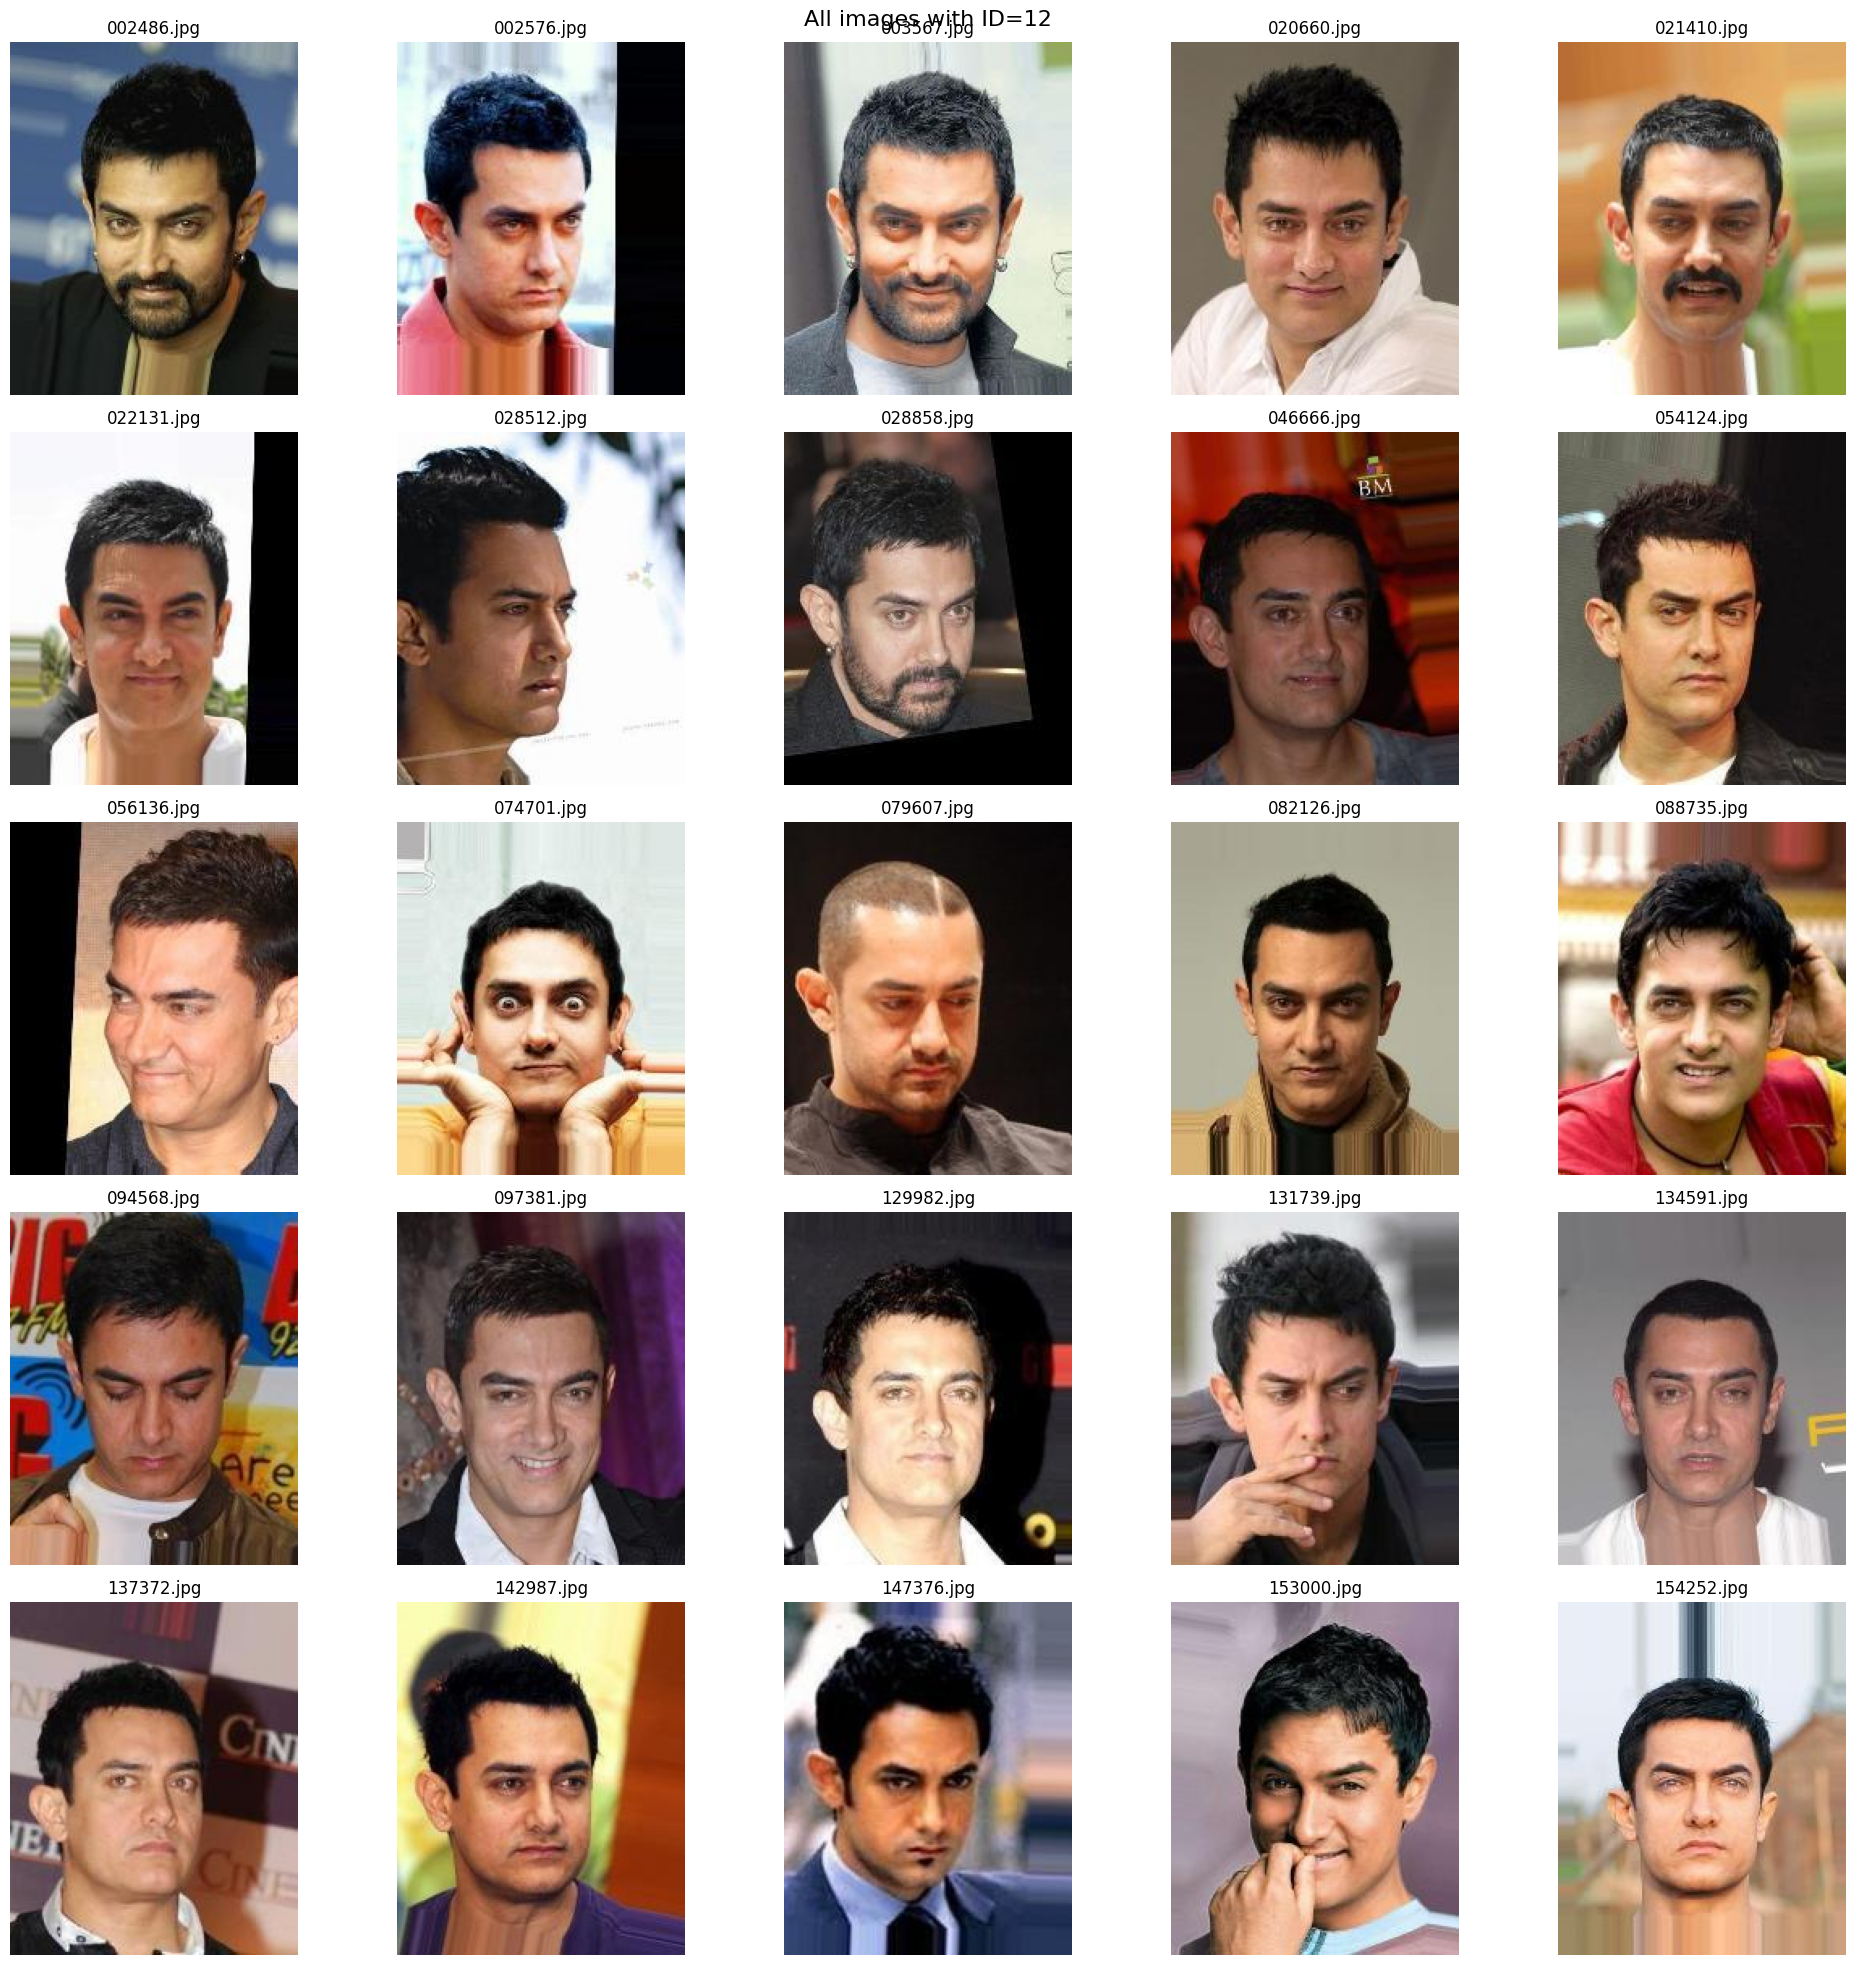

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_dir = "/vol/ideadata/ed52egek/pycharm/syneverything/datasets/celeba/2/img_align_celeba/img_align_celeba"
paths = df[df["id"] == 12]["path"].values

# Calculate grid dimensions
n_images = len(paths)
grid_size = int(np.ceil(np.sqrt(n_images)))

# Create subplot grid
fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))
fig.suptitle("All images with ID=12", fontsize=16)

# Plot each image
for idx, path in enumerate(paths):
    row = idx // grid_size
    col = idx % grid_size
    
    img_path = os.path.join(base_dir, path)
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(path)

# Remove empty subplots
for idx in range(n_images, grid_size * grid_size):
    row = idx // grid_size
    col = idx % grid_size
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

In [41]:
[x for x in df.columns.to_list() if "Hair" in x]

['Black_Hair',
 'Blond_Hair',
 'Brown_Hair',
 'Gray_Hair',
 'Receding_Hairline',
 'Straight_Hair',
 'Wavy_Hair']

In [ ]:
hair_df = df[df[["Bald", "Black_Hair", "Blond_Hair", "Gray_Hair", "Brown_Hair"]].sum(axis=1) == 1]

,path,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,id,Split
0,000001.jpg,0,1,1,0,0,0,0,0,0,...,1,0,1,0,1,0,0,1,2880,TRAIN
1,000002.jpg,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,2937,TEST
5,000006.jpg,0,1,1,0,0,0,1,0,0,...,0,1,1,0,1,0,0,1,4153,TEST
6,000007.jpg,1,0,1,1,0,0,1,1,1,...,1,0,0,0,0,0,0,1,9040,VAL
7,000008.jpg,1,1,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,1,6369,TEST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,9761,TRAIN
202595,202596.jpg,0,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,1,7192,TRAIN
202596,202597.jpg,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,9852,TRAIN
202597,202598.jpg,0,1,1,0,0,0,1,0,1,...,0,1,1,0,1,0,0,1,5570,TRAIN
